# 🔥 FireGuard — Video Testing and Evaluation

This notebook runs **the model you trained yourself** (`fireguard_s_v4`) on a real video —
not a ready-made checkpoint from the internet. Thresholds come from that same false-alarm
table (section 12 of the training notebook), not a guess.

### What it does
1. Reads the video frame by frame and runs the model on it
2. A temporal state machine (Hazard Engine) **confirms** the result — a single stray frame doesn't trigger an alarm
3. On every frame: corner brackets, confidence label, semi-transparent fill over the fire region, status-colored border
4. Embeds a beep/siren into the output MP4
5. Saves `events.csv` (every status change) and a snapshot of each escalation

### ⛔ Nothing is displayed during analysis
Only a single progress line (percent / FPS / ETA) is printed — **not** a live frame playback.
When the analysis is done, you see everything at once: a grid of sample frames, a timeline
chart of status, an events table, and the annotated video itself. Exactly what you saw in
earlier tests (`sample_yolo26s_*.png`, `smoketest_*.png`) — now with our own model.

### Section map
| # | Section |
|---|---|
| 1 | Install |
| 2-7 | The FireGuard engine (from `fireguard_core.py` — untouched) |
| 8 | **Settings ← the only cell you touch** |
| 9 | Loading the model and video |
| 10 | 🎬 Running the analysis (no live display) |
| 11 | 📊 Results — sample frames, chart, events, final video |
| 12 | (optional) Batch analysis of multiple videos |


## 1 · Install
If you're on Colab, `ffmpeg` is already installed (needed for audio muxing and H.264 encoding).


In [1]:
%pip install -q ultralytics opencv-python-headless matplotlib pandas

import shutil
print('ffmpeg:', '✅ هست' if shutil.which('ffmpeg') else '❌ نیست — صدا/انکود نهایی رد می‌شود')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 6.7 MB/s eta 0:00:00
ffmpeg: ✅ هست


## 2 · The FireGuard engine

The sections below are taken verbatim from `fireguard_core.py` — **the same tested code**, not a rewrite.
If you later change the detection/alert logic, change that file and rebuild this notebook
(`py -3 build_eval_notebook.py`) — don't edit these cells by hand.


In [2]:
# FireGuard — real-time fire & smoke intelligence on video
import os
import csv
import time
import math
import wave
import shutil
import warnings
import subprocess
from dataclasses import dataclass
from collections import deque

import cv2
import numpy as np
import torch

warnings.filterwarnings("ignore")


### 3 · Base settings — overridden further down (section 8); this is just the defaults and profiles


In [3]:
CONFIG = {
    # --- model ---
    "model": "yolo26s",          # default & recommended; alternates below stay available
    "imgsz": 640,
    "iou": 0.45,

    # --- operating profile (presets) ---
    # standard    : fire + smoke, balanced thresholds (default)
    # fire-only   : ignore smoke entirely (government / open-terrain mode)
    # early-smoke : ultra-sensitive smoke -> earliest possible warning
    "profile": "standard",

    # --- per-class confidence (overridden by profile unless set here) ---
    "conf_fire": None,           # None -> take from profile
    "conf_smoke": None,

    # --- speed ---
    "frame_skip": 1,             # run inference every Nth frame (1 = every frame)
    "start_frame": 0,            # begin analysis at this frame (skip intro)
    "max_frames": None,          # stop early (None = whole video)

    # --- robustness (temporal confirmation, kills flicker/false alarms) ---
    "confirm_window": 5,         # look at the last N frames
    "confirm_hits": 2,           # need >= K hits in that window to CONFIRM a class
    "clear_frames": 8,           # hold the alarm this many misses before clearing

    # --- alert tiers (visual + audio) ---
    # SMOKING  (gray frame)    : small smoke only, likely cigarette — no alarm sound
    # WARNING  (orange + beep) : large smoke, fire may be starting — beeper audio
    # DANGER/CRITICAL (red)    : fire confirmed — siren audio + pulsing red border
    "cigarette_max_area_frac": 0.004,   # smoke box smaller than 0.4% of frame -> SMOKING
    "audio_alerts": True,               # embed beep/siren audio into the output MP4
    "alert_cooldown_s": 4.0,            # repeat-alarm interval while hazard is active

    # --- output ---
    "output_dir": "outputs",
    "snapshot": True,            # save evidence PNG on every escalation
    "drive_backup": True,        # Colab: copy results to MyDrive/FireGuard_Outputs
    "display_samples": 6,        # annotated frames returned for inline display

    # --- email alert (best-effort, non-blocking, see EMAIL ALERT section) ---
    "email_alerts": False,             # True -> email the evidence snapshot on confirmed WARNING/DANGER/CRITICAL
    "email_from": None,                # your Gmail address (sender)
    "email_to": None,                  # inbox to notify (can be the same address)
    "email_app_password": None,        # Gmail "App Password" — NEVER your real password; see notebook setup
    "email_min_interval_s": 120.0,     # don't email more often than this even if it keeps re-escalating
}

PROFILES = {
    "standard":    {"fire": True, "smoke": True, "conf_fire": 0.30, "conf_smoke": 0.25},
    "fire-only":   {"fire": True, "smoke": False, "conf_fire": 0.30, "conf_smoke": 0.25},
    "early-smoke": {"fire": True, "smoke": True, "conf_fire": 0.35, "conf_smoke": 0.15},
}


### 4 · Model registry — `load_model` reads both from the registry and from any custom `.pt` path (our own model's path)


In [4]:
MODEL_REGISTRY = {
    "yolo26s": {
        "repo": "SalahALHaismawi/yolov26-fire-detection",
        "file": "best.pt",
        "params": "9.9M",
        "note": "DEFAULT — newest generation, most temporally stable, sees fire + smoke",
    },
    "yolov8n": {
        "repo": "rabahdev/fire-smoke-yolov8n",
        "file": "best.pt",
        "params": "3.0M",
        "note": "optional — fastest, for very weak CPUs / edge boxes",
    },
    "yolo11s": {
        "repo": "leeyunjai/yolo11-firedetect",
        "file": "firedetect-11s.pt",
        "params": "9.4M",
        "note": "optional — middle ground",
    },
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IN_COLAB = False
try:
    from google.colab import drive  # noqa: F401
    IN_COLAB = True
except ImportError:
    pass


def load_model(key: str, cache_dir: str = "models"):
    """Load a model from the registry (cached locally) or a custom .pt path."""
    from ultralytics import YOLO

    if key in MODEL_REGISTRY:
        spec = MODEL_REGISTRY[key]
        local = os.path.join(cache_dir, f"{key}.pt")
        if not os.path.exists(local):
            os.makedirs(cache_dir, exist_ok=True)
            from huggingface_hub import hf_hub_download
            print(f"⬇️  Downloading {key} ({spec['repo']}) ...")
            path = hf_hub_download(repo_id=spec["repo"], filename=spec["file"])
            shutil.copy(path, local)
        weights = local
    elif os.path.isfile(key):
        weights = key
    else:
        raise FileNotFoundError(
            f"Unknown model '{key}'. Choose one of {list(MODEL_REGISTRY)} or pass a .pt path."
        )

    model = YOLO(weights)
    print(f"✅ Loaded '{os.path.basename(weights)}'  |  classes: {list(model.names.values())}  |  device: {DEVICE}")
    return model


### 5 · Detection layer — class-name normalization + confidence/size filtering


In [5]:
def normalize_class(name: str):
    """Map any dataset's label spelling to 'fire' / 'smoke' (or ignore)."""
    n = name.lower()
    if "fire" in n or "flame" in n:
        return "fire"
    if "smoke" in n:
        return "smoke"
    return None  # e.g. yolo26s extra class 'other'


@dataclass
class Detection:
    cls: str
    conf: float
    x1: int
    y1: int
    x2: int
    y2: int

    @property
    def centroid(self):
        return (self.x1 + self.x2) // 2, (self.y1 + self.y2) // 2

    @property
    def area(self):
        return max(0, self.x2 - self.x1) * max(0, self.y2 - self.y1)


def detect(model, frame, cfg) -> list:
    """Run inference + per-class confidence & size filtering."""
    conf_fire = cfg["_conf_fire"]
    conf_smoke = cfg["_conf_smoke"]
    min_area = 0.0008 * frame.shape[0] * frame.shape[1]

    results = model.predict(
        source=frame,
        imgsz=cfg["imgsz"],
        conf=min(conf_fire, conf_smoke),
        iou=cfg["iou"],
        device=DEVICE,
        verbose=False,
    )

    dets = []
    for box in results[0].boxes:
        cls = normalize_class(model.names[int(box.cls[0])])
        if cls is None or not cfg["_use"].get(cls, False):
            continue
        conf = float(box.conf[0])
        if conf < (conf_fire if cls == "fire" else conf_smoke):
            continue
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        d = Detection(cls, conf, x1, y1, x2, y2)
        if d.area < min_area:
            continue
        dets.append(d)
    return dets


### 6 · Hazard engine — temporal confirmation
A single positive frame doesn't trigger an alarm; it must be seen in `confirm_hits` out of the last `confirm_window` frames.
A single negative frame doesn't clear an active alarm either; `clear_frames` must be absent consecutively (anti-flicker).


In [6]:
HAZARD_STATES = {
    "SAFE":     {"color": (89, 199, 52),   "label": "SAFE"},
    "CAUTION":  {"color": (10, 214, 255),  "label": "SIGHTING (unconfirmed)"},
    "SMOKING":  {"color": (170, 170, 170), "label": "SMOKING / CIGARETTE"},     # gray frame
    "WARNING":  {"color": (0, 165, 255),   "label": "EARLY FIRE — SMOKE"},      # orange + beeper
    "DANGER":   {"color": (48, 59, 255),   "label": "FIRE — SIREN"},            # red
    "CRITICAL": {"color": (48, 59, 255),   "label": "FIRE + SMOKE — SIREN"},    # red, stronger
}
_ORDER = ["SAFE", "CAUTION", "SMOKING", "WARNING", "DANGER", "CRITICAL"]


class HazardEngine:
    """Confirms classes over time so one flickering frame can't raise an alarm,
    and one missed frame can't silently clear one (hysteresis).
    Confirmed smoke is split into two tiers by box size:
    small -> SMOKING (cigarette, gray), large -> WARNING (early fire, orange)."""

    def __init__(self, cfg):
        self.w = cfg["confirm_window"]
        self.k = cfg["confirm_hits"]
        self.clear = cfg.get("clear_frames", 8)
        self.cig_frac = cfg.get("cigarette_max_area_frac", 0.004)
        self.hist = {"fire": deque(maxlen=self.w), "smoke": deque(maxlen=self.w)}
        self.miss = {"fire": self.clear, "smoke": self.clear}
        self.active = {"fire": False, "smoke": False}
        self.state = "SAFE"
        self.cooldown_s = cfg["alert_cooldown_s"]
        self._last_alarm_t = 0.0

    def update(self, dets, frame_area) -> dict:
        present = {"fire": any(d.cls == "fire" for d in dets),
                   "smoke": any(d.cls == "smoke" for d in dets)}
        for c, hit in present.items():
            self.hist[c].append(hit)
            if hit:
                self.miss[c] = 0
            else:
                self.miss[c] += 1
            if not self.active[c] and sum(self.hist[c]) >= self.k:
                self.active[c] = True                       # confirm
            elif self.active[c] and self.miss[c] >= self.clear:
                self.active[c] = False                      # clear (hysteresis)

        fire, smoke = self.active["fire"], self.active["smoke"]
        smoke_frac = max((d.area for d in dets if d.cls == "smoke"), default=0) / max(frame_area, 1)
        big_smoke = smoke and smoke_frac >= self.cig_frac

        if fire and smoke:
            state = "CRITICAL"
        elif fire:
            state = "DANGER"
        elif smoke and big_smoke:
            state = "WARNING"          # early fire — orange + beeper
        elif smoke:
            state = "SMOKING"          # cigarette — gray frame
        elif any(present.values()):
            state = "CAUTION"
        else:
            state = "SAFE"

        changed = state != self.state
        escalated = _ORDER.index(state) > _ORDER.index(self.state)
        self.state = state

        now = time.time()
        repeat = (
            state in ("DANGER", "CRITICAL")
            and not changed
            and now - self._last_alarm_t >= self.cooldown_s
        )
        if changed or repeat:
            self._last_alarm_t = now

        return {
            "state": state,
            "changed": changed,
            "escalated": escalated,
            "confirmed_fire": fire,
            "confirmed_smoke": smoke,
            "smoke_frac": smoke_frac,
        }


### 7 · Overlay rendering + alarm sound


In [7]:
FIRE_COLOR = (48, 59, 255)      # #FF3B30
SMOKE_COLOR = (0, 196, 255)     # #FFC400


def _blend(img, x1, y1, x2, y2, color, alpha):
    """Alpha-blend a solid color over a rectangular region, in place."""
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
    if x2 <= x1 or y2 <= y1:
        return
    roi = img[y1:y2, x1:x2]
    img[y1:y2, x1:x2] = (roi * (1 - alpha) + np.array(color, dtype=np.float32) * alpha).astype(np.uint8)


def _chip(img, text, x, y, color, scale=0.55, thick=2, pad=6, text_color=(255, 255, 255)):
    """Text on a filled label chip; returns bottom-left of the chip."""
    (tw, th), bl = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, thick)
    h = th + 2 * pad
    y0 = y - h if y - h >= 0 else y          # flip below if clipped at top
    _blend(img, x, y0, x + tw + 2 * pad, y0 + h, color, 0.85)
    cv2.putText(img, text, (x + pad, y0 + h - pad - bl + 1),
                cv2.FONT_HERSHEY_SIMPLEX, scale, text_color, thick, cv2.LINE_AA)
    return y0


def _brackets(img, x1, y1, x2, y2, color, thick=3):
    """Professional corner brackets instead of a full rectangle."""
    l = int(np.clip(0.22 * min(x2 - x1, y2 - y1), 10, 36))
    for (px, py, dx, dy) in [(x1, y1, 1, 1), (x2, y1, -1, 1), (x1, y2, 1, -1), (x2, y2, -1, -1)]:
        cv2.line(img, (px, py), (px + dx * l, py), color, thick, cv2.LINE_AA)
        cv2.line(img, (px, py), (px, py + dy * l), color, thick, cv2.LINE_AA)


def _dashed_circle(img, center, radius, color, n_seg=20, thick=2, alpha=0.0):
    step = int(360 / n_seg)
    overlay = img.copy() if alpha else img
    for a in range(0, 360, 2 * step):
        cv2.ellipse(overlay, center, (radius, radius), 0, a, a + step, color, thick, cv2.LINE_AA)
    if alpha:
        cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)


def draw_overlay(frame, dets, eng_info, stats, t_idx) -> np.ndarray:
    """All visual annotation: state styling, region marking, HUD, borders."""
    img = frame.copy()
    H, W = img.shape[:2]
    state = eng_info["state"]
    sc = HAZARD_STATES[state]["color"]

    # --- cigarette mode: grayscale frame, region still marked on top ---
    if state == "SMOKING":
        img = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)

    # --- per-detection annotation (region marking in EVERY state) ---
    for d in dets:
        color = FIRE_COLOR if d.cls == "fire" else SMOKE_COLOR
        if d.cls == "fire":
            _blend(img, d.x1, d.y1, d.x2, d.y2, color, 0.14)     # highlighted fire region
        _brackets(img, d.x1, d.y1, d.x2, d.y2, color)
        icon = "FIRE" if d.cls == "fire" else "SMOKE"
        _chip(img, f"{icon} {d.conf * 100:.1f}%", d.x1, d.y1 - 6, color)

        if d.cls == "fire":                                       # safety zone around the fire
            cx, cy = d.centroid
            r = int(0.65 * max(d.x2 - d.x1, d.y2 - d.y1))
            _dashed_circle(img, (cx, cy), r, FIRE_COLOR, thick=2, alpha=0.45)
            cv2.line(img, (cx - 10, cy), (cx + 10, cy), FIRE_COLOR, 2, cv2.LINE_AA)
            cv2.line(img, (cx, cy - 10), (cx, cy + 10), FIRE_COLOR, 2, cv2.LINE_AA)

    # --- alert borders: red pulsing for fire, orange pulsing for early smoke,
    #     static gray frame border for cigarette mode ---
    if state in ("DANGER", "CRITICAL"):
        a = 0.30 + 0.22 * math.sin(2 * math.pi * t_idx / 15.0)
        b = 8 if state == "CRITICAL" else 5
        _blend(img, 0, 0, W, b, sc, a)
        _blend(img, 0, H - b, W, H, sc, a)
        _blend(img, 0, 0, b, H, sc, a)
        _blend(img, W - b, 0, W, H, sc, a)
    elif state == "WARNING":
        a = 0.30 + 0.18 * math.sin(2 * math.pi * t_idx / 10.0)
        _blend(img, 0, 0, W, 5, sc, a)
        _blend(img, 0, H - 5, W, H, sc, a)
        _blend(img, 0, 0, 5, H, sc, a)
        _blend(img, W - 5, 0, W, H, sc, a)
    elif state == "SMOKING":
        _blend(img, 0, 0, W, 3, sc, 0.45)
        _blend(img, 0, H - 3, W, H, sc, 0.45)
        _blend(img, 0, 0, 3, H, sc, 0.45)
        _blend(img, W - 3, 0, W, H, sc, 0.45)

    # --- HUD (top-left, always on top) ---
    hud1 = f"FireGuard  |  {HAZARD_STATES[state]['label']}"
    hud2 = (f"{stats['fps']:.1f} FPS  |  fire:{stats['n_fire']}  smoke:{stats['n_smoke']}"
            f"  |  frame {stats['frame']}")
    scale = 0.55 if H >= 480 else 0.45
    y0 = _chip(img, hud1, 10, 12, sc, scale=scale)
    _chip(img, hud2, 10, y0 + 4, (20, 20, 20), scale=scale * 0.92, thick=1,
          text_color=(240, 240, 240), pad=5)
    return img


In [8]:
def _build_alert_audio(timeline, fps, path, sr=22050):
    """Synthesize a mono WAV with beep patterns for WARNING and DANGER/CRITICAL
    stretches. Returns True if the track has any sound."""
    try:
        states = [e["state"] for e in timeline]
        if not states:
            return False
        dur = len(states) / fps + 0.5
        n = int(dur * sr)
        t = np.arange(n) / sr

        def sample_mask(frame_mask):
            reps = int(np.ceil(sr / fps))
            m = np.repeat(frame_mask, reps)
            return m[:n] if len(m) >= n else np.pad(m, (0, n - len(m)))

        warn = sample_mask(np.array([s == "WARNING" for s in states]))
        fire = sample_mask(np.array([s in ("DANGER", "CRITICAL") for s in states]))
        audio = np.zeros(n)
        if warn.any():                                   # 2 Hz beeps @ 880 Hz
            audio += warn * (np.sin(2 * np.pi * 2.0 * t) > 0) * 0.55 * np.sin(2 * np.pi * 880 * t)
        if fire.any():                                   # urgent 4 Hz siren @ 1200 Hz
            audio += fire * (np.sin(2 * np.pi * 4.0 * t) > 0) * 0.8 * np.sin(2 * np.pi * 1200 * t)
        if not audio.any():
            return False

        pcm = (np.clip(audio, -1, 1) * 32767).astype("<i2")
        with wave.open(path, "wb") as w:
            w.setnchannels(1)
            w.setsampwidth(2)
            w.setframerate(sr)
            w.writeframes(pcm.tobytes())
        return True
    except Exception as e:                                # audio is best-effort
        print(f"   ⚠️ audio track skipped: {e}")
        return False


def _mux_audio(video, wav, out):
    r = subprocess.run(
        ["ffmpeg", "-y", "-i", video, "-i", wav,
         "-map", "0:v:0", "-map", "1:a:0", "-c:v", "copy", "-c:a", "aac",
         "-shortest", out],
        capture_output=True,
    )
    return r.returncode == 0


def _drive_backup(cfg):
    """Colab only: copy results to MyDrive/FireGuard_Outputs."""
    if not (IN_COLAB and cfg.get("drive_backup", True)):
        return None
    src_dir = cfg["output_dir"]
    dest = "/content/drive/MyDrive/FireGuard_Outputs"
    try:
        os.makedirs(dest, exist_ok=True)
        for f in os.listdir(src_dir):
            p = os.path.join(src_dir, f)
            if os.path.isfile(p):
                shutil.copy2(p, dest)
        snaps = os.path.join(src_dir, "snapshots")
        if os.path.isdir(snaps):
            shutil.copytree(snaps, os.path.join(dest, "snapshots"), dirs_exist_ok=True)
        return dest
    except Exception as e:
        print(f"   ⚠️ Drive backup failed: {e}")
        return None


### 7.5 · Email alerts — only on a real transition, not every raw frame
`send_alert_email` is only called when the **confirmed** status (after several frames, per
the hazard engine above) reaches `WARNING`/`DANGER`/`CRITICAL` — not every raw single-frame detection.
Sending happens on a **background thread** so the network never slows down the main loop.


In [9]:
import smtplib
import ssl
import threading
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.image import MIMEImage
from email.utils import make_msgid

# look + wording per confirmed tier — CRITICAL gets the loudest banner
_EMAIL_STYLE = {
    "WARNING":  {"emoji": "🟠",       "headline": "FIRE WARNING — early smoke",     "color": "#FF8C00"},
    "DANGER":   {"emoji": "🚨",       "headline": "FIRE ALERT — action needed",     "color": "#E53935"},
    "CRITICAL": {"emoji": "🚨🚨",     "headline": "CRITICAL FIRE ALERT",            "color": "#B71C1C"},
}


def send_alert_email(cfg, state, raw_path, annotated_path, time_s, det_summary="", thread_ref=None):
    """Fire-and-forget: emails a rich HTML alert (raw frame + annotated/detected
    frame, shown inline) via Gmail SMTP in a background thread, so a slow/failed
    network call never stalls the video loop. Requires cfg['email_from'],
    cfg['email_to'], cfg['email_app_password'] (a Gmail "App Password", generated
    at myaccount.google.com -> Security -> App passwords — never your real
    Gmail password)."""
    if not cfg.get("email_alerts"):
        return
    missing = [k for k in ("email_from", "email_to", "email_app_password") if not cfg.get(k)]
    if missing:
        print(f"   ⚠️ email_alerts=True but missing: {', '.join(missing)} — skipped")
        return

    msgid = make_msgid(domain="fireguard.local")

    def _work():
        try:
            sty = _EMAIL_STYLE.get(state, {"emoji": "🔥", "headline": f"{state} detected", "color": "#E53935"})
            subject = f"{sty['emoji']} FireGuard — {sty['headline']} {sty['emoji']}"

            msg = MIMEMultipart("related")
            msg["Subject"] = subject if not thread_ref else f"Re: {subject}"
            msg["From"] = cfg["email_from"]
            msg["To"] = cfg["email_to"]
            msg["Message-ID"] = msgid
            if thread_ref:
                msg["In-Reply-To"] = thread_ref
                msg["References"] = thread_ref

            alt = MIMEMultipart("alternative")
            msg.attach(alt)
            alt.attach(MIMEText(
                f"{sty['headline']}\n\nState: {state}\nVideo time: {time_s:.1f}s\n"
                f"Detections: {det_summary or '-'}\n\nAutomated alert from FireGuard.",
                "plain",
            ))
            alt.attach(MIMEText(f"""\
<div style="font-family:Arial,Helvetica,sans-serif;max-width:640px;margin:auto;
            border:1px solid #eee;border-radius:8px;overflow:hidden">
  <div style="background:{sty['color']};color:#fff;padding:20px;text-align:center">
    <div style="font-size:26px;font-weight:700;line-height:1.3">{sty['emoji']} {sty['headline']} {sty['emoji']}</div>
    <div style="font-size:13px;opacity:.9;margin-top:6px">FireGuard automated alert</div>
  </div>
  <div style="padding:18px 20px">
    <table style="width:100%;font-size:14px;color:#333;border-collapse:collapse;margin-bottom:16px">
      <tr><td style="padding:4px 0;width:120px"><b>State</b></td><td>{state}</td></tr>
      <tr><td style="padding:4px 0"><b>Video time</b></td><td>{time_s:.1f}s</td></tr>
      <tr><td style="padding:4px 0"><b>Detections</b></td><td>{det_summary or '-'}</td></tr>
    </table>
    <table style="width:100%"><tr>
      <td style="width:50%;padding:4px;vertical-align:top">
        <div style="font-size:11px;letter-spacing:.05em;color:#888;margin-bottom:4px">RAW FRAME</div>
        <img src="cid:raw_frame" style="width:100%;border-radius:6px;border:1px solid #ddd">
      </td>
      <td style="width:50%;padding:4px;vertical-align:top">
        <div style="font-size:11px;letter-spacing:.05em;color:#888;margin-bottom:4px">DETECTED REGION</div>
        <img src="cid:annotated_frame" style="width:100%;border-radius:6px;border:1px solid #ddd">
      </td>
    </tr></table>
    <p style="font-size:12px;color:#999;margin-top:18px">
      Automated alert — no action was taken on your behalf. Please verify before responding.
    </p>
  </div>
</div>""", "html"))

            for cid, path in (("raw_frame", raw_path), ("annotated_frame", annotated_path)):
                if path and os.path.exists(path):
                    with open(path, "rb") as f:
                        img = MIMEImage(f.read())
                    img.add_header("Content-ID", f"<{cid}>")
                    img.add_header("Content-Disposition", "inline", filename=os.path.basename(path))
                    msg.attach(img)

            ctx = ssl.create_default_context()
            with smtplib.SMTP_SSL("smtp.gmail.com", 465, context=ctx) as s:
                s.login(cfg["email_from"], cfg["email_app_password"])
                s.sendmail(cfg["email_from"], [cfg["email_to"]], msg.as_string())
            print(f"   📧 alert email sent -> {cfg['email_to']}")
        except Exception as e:                                   # email is best-effort
            print(f"   ⚠️ email alert failed: {e}")

    threading.Thread(target=_work, daemon=True).start()
    return msgid


### 7.6 · Log gating — why analysis was getting slower
`SAFE`↔`CAUTION` is a raw, **not-yet-confirmed** detection and can flicker every frame. The
previous version printed on every flicker **and also wrote a PNG to disk** on each one —
that's what was slowing analysis down. Now printing/events/snapshots/emails only fire on a
**real** transition (`SMOKING`/`WARNING`/`DANGER`/`CRITICAL`); the on-frame HUD is unchanged,
only the logging channel got quieter and faster.


In [10]:
def _resolve_profile(cfg):
    prof = PROFILES[cfg["profile"]]
    cfg["_use"] = {"fire": prof["fire"], "smoke": prof["smoke"]}
    cfg["_conf_fire"] = cfg["conf_fire"] if cfg["conf_fire"] is not None else prof["conf_fire"]
    cfg["_conf_smoke"] = cfg["conf_smoke"] if cfg["conf_smoke"] is not None else prof["conf_smoke"]
    return cfg


def _fmt_eta(s):
    return f"{int(s // 60):02d}:{int(s % 60):02d}"


def process_video(model, cfg, src, out_name="result.mp4", max_frames=None, quiet=False):
    """Main loop: read -> detect -> confirm -> annotate -> write + log + audio."""
    cfg = _resolve_profile(dict(cfg))
    max_frames = max_frames or cfg["max_frames"]

    cap = cv2.VideoCapture(src)
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {src}")
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    os.makedirs(cfg["output_dir"], exist_ok=True)
    snap_dir = os.path.join(cfg["output_dir"], "snapshots")
    os.makedirs(snap_dir, exist_ok=True)
    temp = os.path.join(cfg["output_dir"], "_temp.mp4")
    final = os.path.join(cfg["output_dir"], out_name)
    writer = cv2.VideoWriter(temp, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))

    eng = HazardEngine(cfg)
    events, samples = [], []
    for _ in range(cfg.get("start_frame", 0)):   # fast-forward without decoding
        if not cap.grab():
            break
    n_total = min(total - cfg.get("start_frame", 0), max_frames) if max_frames else total - cfg.get("start_frame", 0)
    sample_at = set(np.linspace(0, max(n_total - 1, 1), cfg["display_samples"]).astype(int)) if n_total > 1 else {0}
    print_every = max(n_total // 25, 1)

    if not quiet:
        est = n_total * 0.15 if DEVICE == "cpu" else n_total * 0.02
        print(f"🎥 {W}x{H} @ {fps:.0f}fps — {n_total} frames to process"
              f"  (rough ETA on {DEVICE.upper()}: ~{_fmt_eta(est)})")

    stats = {"fps": 0.0, "n_fire": 0, "n_smoke": 0, "frame": 0}
    t0, frames_done, det_frames, det_time = time.time(), 0, 0, 0.0
    fire_ever, smoke_ever = False, False
    timeline = []               # per-frame state history for the summary plot + audio
    last_dets = []
    last_info = {"state": "SAFE", "changed": False, "escalated": False,
                 "confirmed_fire": False, "confirmed_smoke": False, "smoke_frac": 0.0}
    emap = {"SAFE": "🟢", "CAUTION": "🟡", "SMOKING": "🚬", "WARNING": "🟠",
            "DANGER": "🚨", "CRITICAL": "🚨🚨"}

    # --- log-tier gating: SAFE/CAUTION are raw, unconfirmed noise (can flicker every
    # frame) and must NEVER hit disk or the console — that's what was slowing things
    # down. Only a real, temporally-confirmed tier (SMOKING/WARNING/DANGER/CRITICAL)
    # triggers a print line, an events.csv row, a snapshot PNG, or an email. ---
    LOG_TIERS = ("QUIET", "SMOKING", "WARNING", "DANGER", "CRITICAL")
    EMAIL_TIERS = ("WARNING", "DANGER", "CRITICAL")   # SMOKING (cigarette-tier) is not alarm-worthy

    def _bucket(state):
        return state if state in LOG_TIERS else "QUIET"

    last_bucket, last_email_t = "QUIET", -1e9
    last_email_conf, email_thread_id = 0.0, None
    EMAIL_MIN_CONF = 0.50   # only ever email when confidence is above this
    EMAIL_CONF_STEP = 0.05  # resend if confidence climbs at least this much further

    while True:
        ret, frame = cap.read()
        if not ret or (max_frames and frames_done >= max_frames):
            break
        idx = frames_done
        frames_done += 1

        if idx % cfg["frame_skip"] == 0:
            ti = time.time()
            dets = detect(model, frame, cfg)
            det_time += time.time() - ti
            det_frames += 1
            last_dets = dets
        else:
            dets = last_dets  # reuse boxes between skipped inferences

        info = eng.update(dets, W * H)
        stats.update(n_fire=sum(d.cls == "fire" for d in dets),
                     n_smoke=sum(d.cls == "smoke" for d in dets), frame=idx + 1)
        stats["fps"] = (idx + 1) / max(time.time() - t0, 1e-6)

        annotated = draw_overlay(frame, dets, info, stats, t_idx=idx)

        # --- event logging: only on a real (confirmed) tier transition, never on
        # raw SAFE/CAUTION flicker (see LOG_TIERS note above) ---
        bucket = _bucket(info["state"])
        log_changed = bucket != last_bucket
        log_escalated = log_changed and LOG_TIERS.index(bucket) > LOG_TIERS.index(last_bucket)
        if log_changed:
            t_s = round(idx / fps, 2)
            msg = f"{emap[info['state']]} frame {idx + 1}: state -> {info['state']}"
            if not quiet:
                print(msg)
            events.append({"frame": idx + 1, "time_s": t_s,
                           "state": info["state"],
                           "fire": stats["n_fire"], "smoke": stats["n_smoke"]})
            snap_path, raw_path = None, None
            if cfg["snapshot"] and log_escalated:
                snap_path = os.path.join(snap_dir, f"{info['state']}_{idx + 1:06d}_detected.png")
                raw_path = os.path.join(snap_dir, f"{info['state']}_{idx + 1:06d}_raw.png")
                cv2.imwrite(snap_path, annotated)
                cv2.imwrite(raw_path, frame)
            if bucket in EMAIL_TIERS:
                fires = [d.conf for d in dets if d.cls == "fire"]
                smokes = [d.conf for d in dets if d.cls == "smoke"]
                max_conf = max(fires + smokes, default=0.0)
                # send on first crossing into an alarm tier, on escalation to a worse
                # tier (e.g. smoke -> fire), or whenever confidence climbs meaningfully —
                # never gated by a fixed cooldown, so a real fire right after smoke still fires
                should_send = (max_conf >= EMAIL_MIN_CONF and
                               (log_escalated or max_conf >= last_email_conf + EMAIL_CONF_STEP))
                if should_send:
                    parts = ([f"fire {max(fires) * 100:.0f}%"] if fires else []) + \
                            ([f"smoke {max(smokes) * 100:.0f}%"] if smokes else [])
                    email_thread_id = send_alert_email(cfg, info["state"], raw_path, snap_path, t_s,
                                                        ", ".join(parts), thread_ref=email_thread_id)
                    last_email_t = time.time()
                    last_email_conf = max_conf
            elif bucket not in ("SMOKING",):
                # back to QUIET: incident is over, next alarm starts a fresh email thread
                last_email_conf, email_thread_id = 0.0, None
            last_bucket = bucket
        fire_ever |= info["confirmed_fire"]
        smoke_ever |= info["confirmed_smoke"]
        timeline.append({"frame": idx + 1, "time_s": round(idx / fps, 2),
                         "state": info["state"], "n_fire": stats["n_fire"],
                         "n_smoke": stats["n_smoke"]})

        if idx in sample_at:
            samples.append(annotated)
        writer.write(annotated)

        # --- progress with ETA (visible end in sight) ---
        if not quiet and ((idx + 1) % print_every == 0 or idx + 1 == n_total):
            elapsed = time.time() - t0
            eta = elapsed / (idx + 1) * (n_total - idx - 1)
            print(f"   ▏{100 * (idx + 1) / n_total:5.1f}%  ({idx + 1}/{n_total})  "
                  f"{stats['fps']:.1f} FPS  |  ETA {_fmt_eta(eta)}  |  {emap[info['state']]} {info['state']}")

    cap.release()
    writer.release()

    # events CSV
    if events:
        with open(os.path.join(cfg["output_dir"], "events.csv"), "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=["frame", "time_s", "state", "fire", "smoke"])
            w.writeheader()
            w.writerows(events)

    # encode to H.264, then mux the beep/siren track (best effort)
    if shutil.which("ffmpeg"):
        r = subprocess.run(["ffmpeg", "-y", "-i", temp, "-vcodec", "libx264", "-crf", "23", final],
                           capture_output=True)
        if r.returncode == 0:
            os.remove(temp)
        else:
            shutil.move(temp, final)
        if cfg.get("audio_alerts", True) and timeline:
            wav = os.path.join(cfg["output_dir"], "_alerts.wav")
            if _build_alert_audio(timeline, fps, wav):
                with_audio = final.replace(".mp4", "_audio.mp4")
                if _mux_audio(final, wav, with_audio):
                    os.replace(with_audio, final)
                os.remove(wav)
    else:
        shutil.move(temp, final)

    drive_dest = _drive_backup(cfg)

    summary = {
        "frames": frames_done,
        "inferences": det_frames,
        "ms_per_inference": 1000 * det_time / max(det_frames, 1),
        "pipeline_fps": frames_done / max(time.time() - t0, 1e-6),
        "events": len(events),
        "fire_seen": fire_ever,
        "smoke_seen": smoke_ever,
        "final_state": eng.state,
        "output": final,
        "drive": drive_dest,
        "timeline": timeline,
    }
    if not quiet:
        print("\n📊 SUMMARY")
        for k, v in summary.items():
            if k != "timeline":
                print(f"   {k:>18}: {v}")
        if drive_dest:
            print(f"\n☁️  Results copied to Google Drive: {drive_dest}")
    return summary, samples


## 8 · Settings — **the only cell you actually touch**

| Option | Meaning |
|---|---|
| `DRIVE_ROOT` | if you're on a second Google account, put the shortcut path here (same as the training notebook) |
| `MODEL_PATH` | default: the final `best.pt` of `fireguard_s_v4` that you trained yourself |
| `VIDEO_SOURCE` | `'drive'` (file in Google Drive) · `'local'` (path on this system/server) · `'upload'` (manual upload) |
| `VIDEO_PATH` | file name or path. If not found exactly, the next section will search Drive/folder for it |
| `PROFILE` | `standard` (fire+smoke) · `fire-only` (fire only) · `early-smoke` (most sensitive to smoke) |
| `CONF` | confidence threshold — **0.25**, the number calibrated in section 12 of the training notebook at a 1% false-alarm rate |
| `EMAIL_ALERTS` | `True` → sends an email with a witness photo on every **confirmed** `WARNING`/`DANGER`/`CRITICAL` escalation (not every raw frame) |


In [21]:
import os

# ═════════════════ paths ═════════════════
DRIVE_ROOT = '/content/drive/MyDrive'# second account? change just this one line
MODEL_PATH = f'{DRIVE_ROOT}/FireGuard_Runs/fireguard_s_v4/final/best.pt'

# ★ video source — pick one of these three:
#   'drive'  → a file you placed in Google Drive (VIDEO_PATH = its name or path under DRIVE_ROOT)
#   'local'  → the full path of a file on this same system/server (no Drive needed)
#   'upload' → opens a manual upload dialog from your computer
VIDEO_SOURCE = 'drive'
VIDEO_PATH   = f'{DRIVE_ROOT}/fire.mp4'# for 'drive': name/path under Drive · for 'local': full path

# ═════════════════ detection behavior ═════════════════
PROFILE = 'standard'   # 'standard' · 'fire-only' · 'early-smoke'
CONF    = 0.25# ★ calibrated from section 12 (FAR 1.0% · detection 98.3%). more sensitive → lower it

# ═════════════════ analysis range ═════════════════
START_FRAME = 0# if you want to start partway through the video
MAX_FRAMES  = None# None = entire video
FRAME_SKIP  = 1# 2 means run inference on every second frame (~2x faster, detections repeat between frames)

# ═════════════════ output ═════════════════
OUTPUT_NAME  = 'fireguard_eval_result.mp4'
DRIVE_BACKUP = True# also copy the result to MyDrive/FireGuard_Outputs

print('مدل    :', MODEL_PATH)
print('منبعِ ویدیو:', VIDEO_SOURCE, '→', VIDEO_PATH if VIDEO_SOURCE != 'upload' else '(با آپلود مشخص می‌شود)')
print(f'پروفایل: {PROFILE}   conf: {CONF}   frame_skip: {FRAME_SKIP}')


مدل    : /content/drive/MyDrive/FireGuard_Runs/fireguard_s_v4/final/best.pt
منبعِ ویدیو: drive → /content/drive/MyDrive/fire.mp4
پروفایل: standard   conf: 0.25   frame_skip: 1


## 8.5 · (optional) Email alerts — one-time setup

**Never type your Gmail app password directly into the notebook**; put it in Colab Secrets so it
stays only in your own browser:

1. `myaccount.google.com` → **Security** → make sure "2-Step Verification" is on
2. In the same place search for **App passwords** → create one for "Mail" → copy the 16-digit code
3. In Colab: the 🔑 icon in the left sidebar → **Add new secret** → name: `GMAIL_APP_PASSWORD` → value: that code → turn on "Notebook access"
4. Below, set `EMAIL_ALERTS = True` and put in your email address

If there's no Colab Secret (e.g. you're running this on your own machine), this same cell
will prompt you with `getpass` — again, nothing gets stored anywhere.


In [20]:
EMAIL_ALERTS  = True# ★ set True to enable this section
EMAIL_FROM    = '1.parsa.karkooti@gmail.com'# sender — this same Gmail account
EMAIL_TO      = 'pkarkooti@gmail.com'# recipient — can be the same address
EMAIL_MIN_INTERVAL_S = 120# at most one email every 120 seconds, even if it keeps escalating

EMAIL_APP_PASSWORD = "cqdurnncbnntldvi"
if EMAIL_ALERTS:
    try:
        from google.colab import userdata
        EMAIL_APP_PASSWORD = userdata.get('GMAIL_APP_PASSWORD')
        print('🔑 رمز از Colab Secrets خوانده شد')
    except Exception:
        import getpass
        EMAIL_APP_PASSWORD = getpass.getpass('Gmail App Password: ')
    if not EMAIL_APP_PASSWORD:
        print('⚠️ رمز خالی است — EMAIL_ALERTS را False کن یا Secret را درست بگذار')
        EMAIL_ALERTS = False
else:
    print('⏭️  هشدارِ ایمیلی خاموش است (EMAIL_ALERTS=False)')


Gmail App Password: ··········


## 9 · Loading Drive, model, and video — smart

If the exact video path is wrong, this cell doesn't fail immediately — instead it **searches
Drive/folder itself for a file with the same name**, and if it's not found, it lists the
available videos so you can quickly tell what the right name/path is.


In [22]:
VIDEO_EXT = ('.mp4', '.mov', '.avi', '.mkv', '.webm')


def _find_video(name_or_path, search_root, max_depth=3):
    # if the exact path wasn't right, look for a file with this same name under search_root's subfolders
    base = os.path.basename(name_or_path).lower()
    hits = []
    for dirpath, dirs, files in os.walk(search_root):
        rel_depth = dirpath[len(search_root):].count(os.sep)
        if rel_depth >= max_depth:
            dirs[:] = []
            continue
        for f in files:
            if f.lower() == base:
                hits.append(os.path.join(dirpath, f))
    return hits


def _list_videos(root, max_depth=2):
    found = []
    for dirpath, dirs, files in os.walk(root):
        rel_depth = dirpath[len(root):].count(os.sep)
        if rel_depth >= max_depth:
            dirs[:] = []
            continue
        found += [os.path.join(dirpath, f) for f in files if f.lower().endswith(VIDEO_EXT)]
    return found


# ── Drive (only if actually needed) ──
if IN_COLAB and (VIDEO_SOURCE == 'drive' or MODEL_PATH.startswith('/content/drive')):
    from google.colab import drive
    drive.mount('/content/drive')

# ── video ──
if VIDEO_SOURCE == 'upload':
    if not IN_COLAB:
        raise RuntimeError("VIDEO_SOURCE='upload' فقط روی Colab کار می‌کند؛ 'local' یا 'drive' بگذار.")
    from google.colab import files
    print('📤 فایلِ ویدیو را انتخاب کن ...')
    up = files.upload()
    VIDEO_PATH = next(iter(up))

elif VIDEO_SOURCE in ('drive', 'local'):
    search_root = DRIVE_ROOT if VIDEO_SOURCE == 'drive' else (os.path.dirname(os.path.abspath(VIDEO_PATH)) or '.')
    if not os.path.exists(VIDEO_PATH):
        print(f'⚠️ در مسیرِ دقیق پیدا نشد: {VIDEO_PATH}\n   دنبالِ «{os.path.basename(VIDEO_PATH)}» در {search_root} می‌گردم ...')
        hits = _find_video(VIDEO_PATH, search_root) if os.path.isdir(search_root) else []
        if hits:
            VIDEO_PATH = hits[0]
            print(f'✅ پیدا شد: {VIDEO_PATH}')
        else:
            avail = _list_videos(search_root) if os.path.isdir(search_root) else []
            hint = '\n     '.join(avail) if avail else '(هیچ ویدیویی پیدا نشد)'
            raise FileNotFoundError(
                f'❌ «{os.path.basename(VIDEO_PATH)}» هیچ‌جا پیدا نشد.\n'
                f'   ویدیوهای موجود در {search_root}:\n     {hint}\n'
                f'   → VIDEO_PATH را در بخشِ ۸ به یکی از این‌ها تغییر بده.'
            )
else:
    raise ValueError("VIDEO_SOURCE باید یکی از 'drive' · 'local' · 'upload' باشد")

assert os.path.exists(VIDEO_PATH), f'❌ ویدیو پیدا نشد: {VIDEO_PATH}'
size_mb = os.path.getsize(VIDEO_PATH) / 1e6
print(f'✅ ویدیو: {VIDEO_PATH}  ({size_mb:.1f} MB)')

# ── model ──
if not os.path.exists(MODEL_PATH):
    run_dir = os.path.dirname(os.path.dirname(MODEL_PATH))
    hint = os.listdir(run_dir) if os.path.isdir(run_dir) else '(پوشه هم پیدا نشد)'
    raise FileNotFoundError(
        f'❌ مدل پیدا نشد: {MODEL_PATH}\n'
        f'   محتوای {run_dir}: {hint}\n'
        f'   → مطمئن شو نوت‌بوکِ آموزش تا بخشِ ۱۴ (ذخیره) کامل اجرا شده.'
    )

model = load_model(MODEL_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ویدیو: /content/drive/MyDrive/fire.mp4  (1.4 MB)
✅ Loaded 'best.pt'  |  classes: ['fire', 'smoke']  |  device: cuda


## 10 · 🎬 Running the analysis

Only a progress line is printed (percent, FPS, ETA, current status) — **no frames are displayed.**
Wait for it to finish, then go to section 11 to see the results.


In [23]:
cfg = dict(CONFIG)
cfg.update(
    profile=PROFILE,
    conf_fire=CONF, conf_smoke=CONF,
    start_frame=START_FRAME, max_frames=MAX_FRAMES, frame_skip=FRAME_SKIP,
    drive_backup=DRIVE_BACKUP,
    email_alerts=EMAIL_ALERTS, email_from=EMAIL_FROM, email_to=EMAIL_TO,
    email_app_password=EMAIL_APP_PASSWORD, email_min_interval_s=EMAIL_MIN_INTERVAL_S,
)

summary, samples = process_video(model, cfg, VIDEO_PATH, out_name=OUTPUT_NAME)


🎥 854x480 @ 25fps — 511 frames to process  (rough ETA on CUDA: ~00:10)
   ▏  3.9%  (20/511)  29.7 FPS  |  ETA 00:16  |  🟢 SAFE
   ▏  7.8%  (40/511)  40.7 FPS  |  ETA 00:11  |  🟢 SAFE
   ▏ 11.7%  (60/511)  45.6 FPS  |  ETA 00:09  |  🟢 SAFE
   ▏ 15.7%  (80/511)  48.5 FPS  |  ETA 00:08  |  🟢 SAFE
   ▏ 19.6%  (100/511)  51.1 FPS  |  ETA 00:08  |  🟢 SAFE
   ▏ 23.5%  (120/511)  52.6 FPS  |  ETA 00:07  |  🟢 SAFE
   ▏ 27.4%  (140/511)  54.0 FPS  |  ETA 00:06  |  🟢 SAFE
   ▏ 31.3%  (160/511)  55.2 FPS  |  ETA 00:06  |  🟢 SAFE
   ▏ 35.2%  (180/511)  55.9 FPS  |  ETA 00:05  |  🟢 SAFE
   ▏ 39.1%  (200/511)  56.7 FPS  |  ETA 00:05  |  🟢 SAFE
   ▏ 43.1%  (220/511)  57.5 FPS  |  ETA 00:05  |  🟢 SAFE
   ▏ 47.0%  (240/511)  58.1 FPS  |  ETA 00:04  |  🟢 SAFE
   ▏ 50.9%  (260/511)  58.5 FPS  |  ETA 00:04  |  🟢 SAFE
   ▏ 54.8%  (280/511)  59.0 FPS  |  ETA 00:03  |  🟢 SAFE
🟠 frame 294: state -> WARNING
   ▏ 58.7%  (300/511)  58.1 FPS  |  ETA 00:03  |  🟠 WARNING
🚬 frame 308: state -> SMOKING
🟠 frame 309: st

## 11 · 📊 Results


  فریم‌ها               : 511
  استنتاج‌ها             : 511
  سرعتِ خالصِ مدل        : 13.2 ms/فریم
  سرعتِ کلِ خط‌لوله      : 24.0 FPS
  آتش دیده شد؟          : ✅ بله
  دود دیده شد؟          : ✅ بله
  تعدادِ تغییرِ وضعیت    : 11
  وضعیتِ نهایی           : CRITICAL


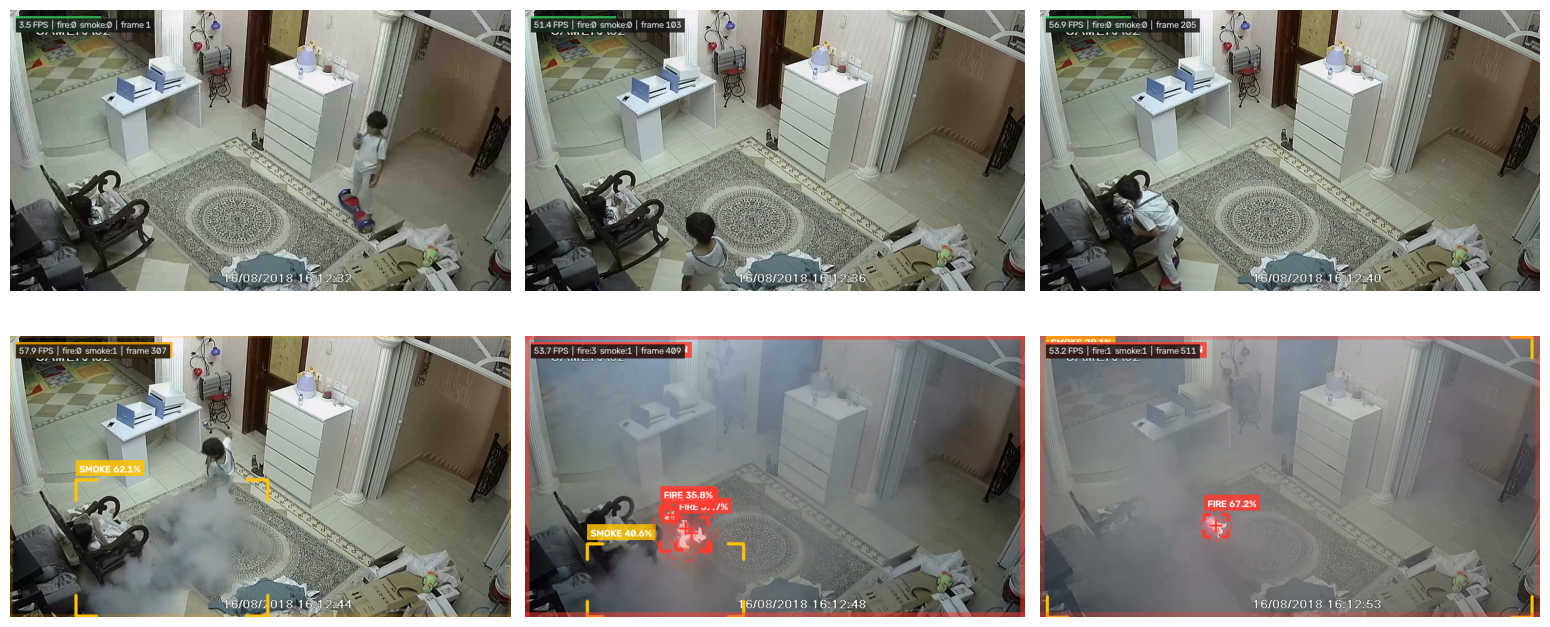

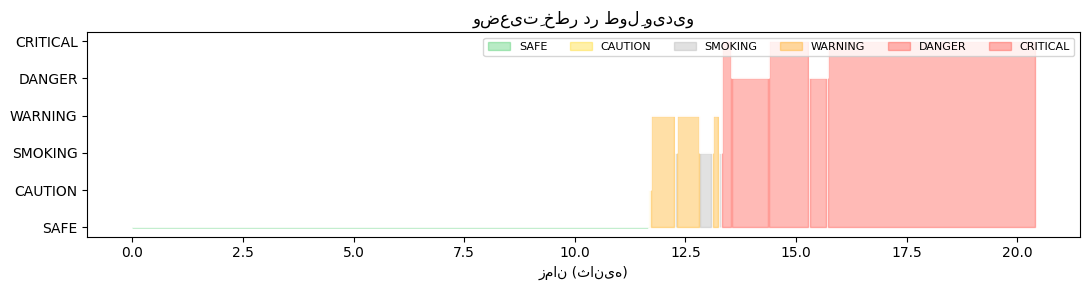

📄 events.csv — هر تغییرِ وضعیت


,frame,time_s,state,fire,smoke
0,294,11.72,WARNING,0,1
1,308,12.28,SMOKING,0,0
2,309,12.32,WARNING,0,1
3,322,12.84,SMOKING,0,0
4,329,13.12,WARNING,0,1
5,333,13.28,SMOKING,1,0
6,334,13.32,CRITICAL,1,0
7,340,13.56,DANGER,1,0
8,361,14.40,CRITICAL,1,1
9,384,15.32,DANGER,1,0


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Video

STATE_ORDER = ["SAFE", "CAUTION", "SMOKING", "WARNING", "DANGER", "CRITICAL"]


def _hex(bgr):
    return "#%02x%02x%02x" % tuple(reversed(bgr))


def show_samples(samples, cols=3):
    """فریم‌های annotated در یک گرید (BGR -> RGB)."""
    if not samples:
        print("نمونه‌ای ذخیره نشد")
        return
    rows = -(-len(samples) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5.2 * cols, 3.6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, img in zip(axes, samples):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()


def plot_timeline(summary):
    """وضعیتِ خطر در طولِ زمان — کلِ حادثه در یک نگاه."""
    df = pd.DataFrame(summary["timeline"])
    if df.empty:
        print("تایم‌لاینی ثبت نشد")
        return
    df["state_idx"] = df["state"].map({s: i for i, s in enumerate(STATE_ORDER)})
    fig, ax = plt.subplots(figsize=(11, 3))
    for s in STATE_ORDER:
        y = df["state_idx"].where(df["state"] == s, np.nan)
        if y.notna().any():
            ax.fill_between(df["time_s"], 0, y, step="post",
                            alpha=0.35, color=_hex(HAZARD_STATES[s]["color"]), label=s)
    ax.step(df["time_s"], df["state_idx"], where="post", color="white", lw=1.2)
    ax.set_yticks(range(len(STATE_ORDER)), STATE_ORDER)
    ax.set_xlabel("زمان (ثانیه)")
    ax.set_title("وضعیتِ خطر در طولِ ویدیو")
    ax.legend(loc="upper right", ncol=6, fontsize=8)
    plt.tight_layout()
    plt.show()


def show_events():
    p = os.path.join(CONFIG["output_dir"], "events.csv")
    if os.path.exists(p):
        print("📄 events.csv — هر تغییرِ وضعیت")
        display(pd.read_csv(p))
    else:
        print("📄 هیچ تغییرِ وضعیتی ثبت نشد — کلِ ویدیو SAFE ماند")


print("=" * 60)
print(f"  فریم‌ها               : {summary['frames']:,}")
print(f"  استنتاج‌ها             : {summary['inferences']:,}")
print(f"  سرعتِ خالصِ مدل        : {summary['ms_per_inference']:.1f} ms/فریم")
print(f"  سرعتِ کلِ خط‌لوله      : {summary['pipeline_fps']:.1f} FPS")
print(f"  آتش دیده شد؟          : {'✅ بله' if summary['fire_seen'] else '❌ نه'}")
print(f"  دود دیده شد؟          : {'✅ بله' if summary['smoke_seen'] else '❌ نه'}")
print(f"  تعدادِ تغییرِ وضعیت    : {summary['events']}")
print(f"  وضعیتِ نهایی           : {summary['final_state']}")
print("=" * 60)

show_samples(samples)
plot_timeline(summary)
show_events()


### Final video (annotated + audio)


In [25]:
from IPython.display import Video, display

print('🎞️  خروجی:', summary['output'])
if summary.get('drive'):
    print('☁️  کپی در Drive:', summary['drive'])

try:
    display(Video(summary['output'], embed=True, width=720))
except Exception as e:
    print(f'⚠️ پخشِ اینلاین نشد ({e}) — فایل را از مسیرِ بالا دانلود کن')


🎞️  خروجی: outputs/fireguard_eval_result.mp4
☁️  کپی در Drive: /content/drive/MyDrive/FireGuard_Outputs


## 12 · (optional) Batch analysis — multiple videos back-to-back

If you have several test clips (e.g. a folder like `optimized_project_videos/fire/` that you
uploaded to Drive), this cell runs through all of them and produces a summary table. Each video
is processed quietly (`quiet=True`); only the final table gets printed.


In [26]:
import glob

BATCH_DIR = f'{DRIVE_ROOT}/fire_test_videos'# ← put the folder of test videos here
RUN_BATCH = False# True to run it

if RUN_BATCH:
    vids = sorted(glob.glob(f'{BATCH_DIR}/*.mp4'))
    print(f'{len(vids)} ویدیو پیدا شد')
    rows = []
    for v in vids:
        name = os.path.basename(v)
        print(f'\n▶️  {name} ...')
        s, _ = process_video(model, cfg, v, out_name=f'batch_{name}', quiet=True)
        rows.append({
            'ویدیو': name, 'فریم': s['frames'], 'FPS': round(s['pipeline_fps'], 1),
            'آتش': s['fire_seen'], 'دود': s['smoke_seen'],
            'تغییرِ وضعیت': s['events'], 'وضعیتِ نهایی': s['final_state'],
        })
    display(pd.DataFrame(rows))
else:
    print('⏭️  خاموش است — RUN_BATCH=True کن تا اجرا شود')


⏭️  خاموش است — RUN_BATCH=True کن تا اجرا شود
